# Study Stripping from First Principles

This follows the implementation of ``test_evolve.py`` in the SatGen repository. The code does 3 things:
1. Initialize a host halo of mass $M_{\rm UFD}$ and a single subhalo with mass $m$
2. Evolve the orbit of the subhalo in the host halo (including dynamical friction)
3. Track the mass loss of the subhalo
We initialize an NFW host halo with a virial mass of $10^9 M_\odot$ and a concentration of $11.68$. This roughly corresponds to the parameters of Segue I, which is one of the most sensitive UFD candidates. For the subhalo we take $m= 10^6 M_\odot$ as an exemplary value.

For all of this we use the SatGen routines since we eventually might also want to use it to generate the initial conditions for the system. It also has an implementation of subhalo stripping. Even though we think this description is not completely realistic and/or applicable to our scenario, it gives us a starting point to compare to.

**To Dos:**
- Run code with SatGen mass stripping and visually reproduce Tidal Tracks from [Errani et al '21](https://academic.oup.com/mnras/article/505/1/18/6271332) (this is trivial since the tidal tracks are implemented in SatGen. But it might still be useful to see that it actually matches the $v_{\rm max} - r_{\rm max}$ curve in the paper)
- Implement first order method from [Pullen et al '14](https://iopscience.iop.org/article/10.1088/0004-637X/792/1/24) (see also [Benson & Du '22](https://academic.oup.com/mnras/article/517/1/1398/6726643)) numerically. See that it slightly deviates from the tidal tracks. But we should try to get it close to what it looks like in Figure 1 of [Benson & Du '22](https://academic.oup.com/mnras/article/517/1/1398/6726643)
- Implement second order method from [Benson & Du '22](https://academic.oup.com/mnras/article/517/1/1398/6726643), including the improved mass shell expansion formalism from [Du et al '24](http://arxiv.org/abs/2403.09597), which avoids shell crossings

**Already Done:**
- Implementation of a numeric profile class in ``subhalo_functions.py``
- A ``heat_profile`` function in ``subhalo_functions.py`` which should perform the shell expansion formalism from http://arxiv.org/abs/2403.09597 (I took it from the Fortran implementation of Galacticus https://github.com/galacticusorg/galacticus)
- An implementation of the tidal tensor computation
- A first try to perform the stripping within this file (don't trust anything... I don't think it's really working yet)

In [1]:
import config as cfg
import cosmo as co
from profiles import NFW, Dekel, Einasto, MN, Vcirc, ftot, fDF, tdyn
from orbit import orbit
import evolve as ev
import galhalo as gh

import aux
from subhalo_functions import heat_profile, NumericProfile, tidalTensor
import stripping_common as sc

import numpy as np
from scipy.optimize import bisect
import time
import sys

import matplotlib as mpl
mpl.rcParams['xtick.direction'] = 'in'
mpl.rcParams['ytick.direction'] = 'in'
mpl.rcParams['font.size'] = 15
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

%matplotlib inline

>>> Normalizing primordial power spectrum P(k)=(k/k_0)^n_s ...
    such that sigma(R=8Mpc/h) =   0.8000.
>>> Tabulating sigma(M,z=0) ...
    From now on, sigma(M,z) is computed by interpolation.
>>> Tabulating z(W) and z(t_lkbk)...
>>> Preparing output redshifts for merger trees ...
    Number of output redshifts =  354, up to z = 20.06
>>> Tabulating Parkinson+08 J(u_res) ...
>>> Building interpolation grid for Green+19 M(<r|f_b,c)...
>>> Building interpolation grid for Green+19 sigma(r|f_b,c)...
>>> Building interpolation grid for Green+19 d2Phidr2(r|f_b,c)...
>>> Building interpolator for Jiang+15 orbit sampler...


## Initialize Subhalo and Host Profile

We initialize the mass resolution, the host profile and the subhalo (including its initial phase space). The subhalo has a Dekel profile (which is the standard in SatGen)

In [2]:
cfg.Mres = 1e1

#---host and satellite parameters
Mv     = 1e9    # host virial mass [Msun]
cNFW   = 11.68  # host NFW concentration
mv0    = 1e6    # satellite virial mass at infall [Msun]
cDekel0 = 100.  # satellite Dekel concentration
aDekel0 = 1.0 + cfg.eps

#---tidal heating parameters
epsh  = 3.
gamma = 2.5

#---time integration
Nstep = 10000
tmax  = 10.  # [Gyr]

#---build host and satellite
hNFW      = NFW(Mv, cNFW)
potential = hNFW
sat_dekel = Dekel(mv0, cDekel0, aDekel0)

#---initial orbital position (circular orbit at R0=1 kpc)
R0, z0 = 0.7*hNFW.rh, 0.
xv0, _    = sc.make_orbit(hNFW, R0=R0, z0=z0, eta=0.5)

print(f"Host  : rh = {hNFW.rh:.2f} kpc, rs = {hNFW.rs:.2f} kpc")
print(f"Sat   : rh = {sat_dekel.rh:.2f} kpc, rs = {sat_dekel.rs:.2f} kpc")
print(f"xv0   : R={xv0[0]:.4f} kpc, Vphi={xv0[4]:.4f} kpc/Gyr")

Host  : rh = 20.63 kpc, rs = 1.77 kpc
Sat   : rh = 2.06 kpc, rs = 0.02 kpc
xv0   : R=14.4402 kpc, Vphi=7.9857 kpc/Gyr


In [3]:
import time
t1 = time.time()
result_A = sc.evolve_satgen_dekel(hNFW, sat_dekel, xv0, tmax=tmax, Nstep=Nstep)
t2 = time.time()
print(f'Baseline A (Dekel/P10): {t2-t1:.2f} s')

Baseline A (Dekel/P10): 4.49 s


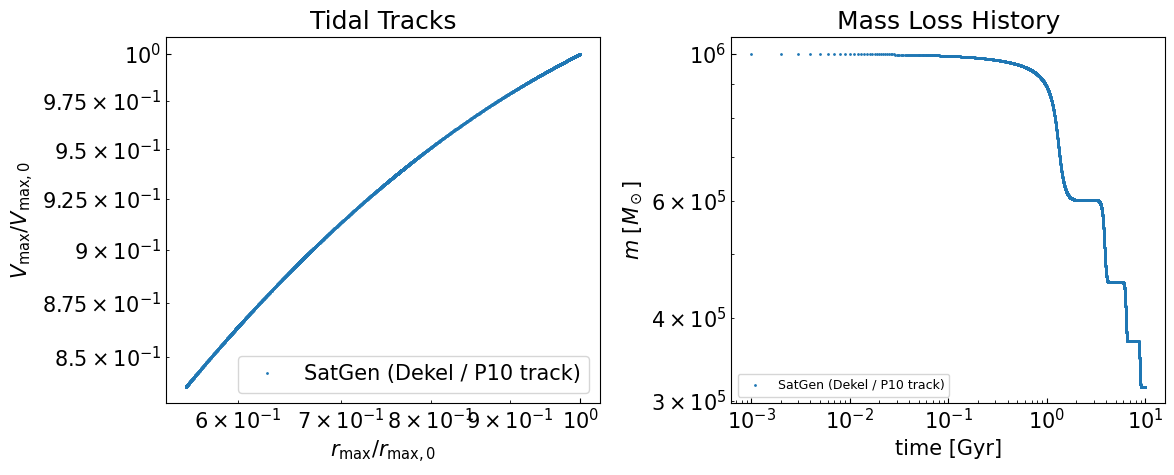

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sc.plot_tidal_track(result_A, ax=axes[0])
sc.plot_mass_loss(result_A, ax=axes[1])
plt.tight_layout()
plt.show()

Now let us try to do the whole calculation with the custom heating procedure

In [5]:
rvals = np.logspace(np.log10(cfg.Rres), np.log10(sat_dekel.rh), 100)
numProfile0 = NumericProfile(rvals, sat_dekel.M(rvals))

t1 = time.time()
result_heat = sc.evolve_heating(hNFW, numProfile0, xv0, tmax=tmax, Nstep=Nstep,
                                epsh=epsh, gamma=gamma)
t2 = time.time()
print(f'Custom heating (Du+24): {t2-t1:.2f} s')

Custom heating (Du+24): 27.67 s


In [ ]:
#---tidal tracks: Baseline A vs custom heating
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sc.plot_tidal_track([result_A, result_heat], ax=axes[0])
sc.plot_mass_loss([result_A, result_heat], ax=axes[1])
plt.tight_layout()
plt.show()

#---profile evolution snapshots (custom heating)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
shared_ylims = sc.profile_ylims(result_heat)
sc.plot_profile_snapshots(result_heat, axes=[axes[0,0], axes[0,1], axes[1,0]], ylims=shared_ylims)
sc.plot_orbit([result_A, result_heat], ax=axes[1,1])
handles, labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles, labels, fontsize=9, loc='lower center',
           bbox_to_anchor=(0.5, -0.04), ncol=5)
plt.tight_layout()
plt.show()

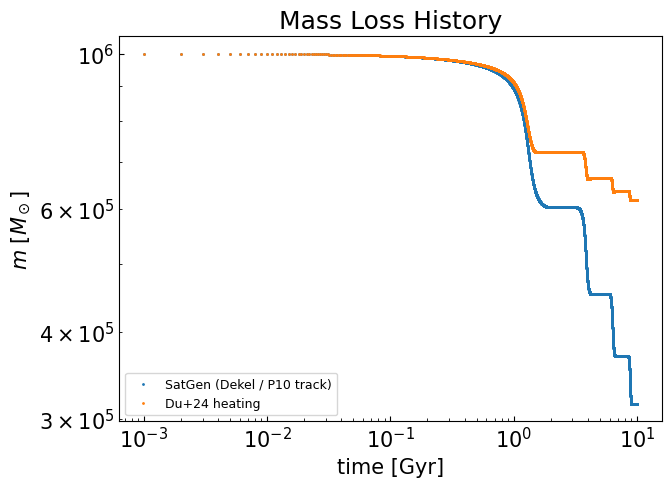

In [7]:
sc.plot_mass_loss([result_A, result_heat])
plt.show()